# Gaussian linear regression: unbiased LOO by stratified path sampling

For each replicate, draw an index $i$ uniformly in $\{0,\ldots,n-1\}$ and estimate

$$
\log p(y_i \mid y_{-i}) = \int_0^1 \mathbb{E}_{\pi_{i,\lambda}}[\log p(y_i \mid \theta)]\,d\lambda,
$$

where $\pi_{i,0}(\theta)=p(\theta \mid y_{-i})$ and $\pi_{i,1}(\theta)=p(\theta \mid y)$. Multiplying by $n$ gives an unbiased estimator of the total LOO ELPD.


In [1]:
from src import *
from tqdm import tqdm
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.integrate import quad
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper")
np.random.seed(2026)


## Simulated Gaussian linear model


In [2]:
n, d = 100, 1
true_theta = np.array([2.5])
X_data = np.random.randn(n, d)
sigma2_noise = 0.4**2
y_data = X_data @ true_theta + np.random.normal(0, np.sqrt(sigma2_noise), size=n)

prior_mean = np.zeros(d)
prior_cov = np.eye(d) * 10.0
prior_precision = np.linalg.inv(prior_cov)

blr_path = BayesianLinearRegressionTempering(
    X_data,
    y_data,
    prior_mean,
    prior_cov,
    sigma2_noise,
)




In [3]:

loo_log_densities_exact, true_value = blr_path.exact_loo_elpd()
print(f"Exact conjugate LOO ELPD: {true_value:.6f}")

Exact conjugate LOO ELPD: -47.551860


## `LOO with path sampling`

The path is the geometric path between the leave-one-out posterior and the full posterior:

$$
\pi_{i,\lambda}(\theta) \propto p(\theta\mid y_{-i})^{1-\lambda}p(\theta\mid y)^\lambda.
$$

Equivalently, up to normalizing constants,

$$
\pi_{i,\lambda}(\theta) \propto p(\theta)\prod_{j\ne i}p(y_j\mid\theta)\,p(y_i\mid\theta)^\lambda.
$$


In [4]:
loo_index = np.random.randint(n)


def log_target0(theta):
    """Unnormalized log posterior without observation loo_index."""
    return blr_path.log_posterior_minus_i(theta, loo_index)


def log_target1(theta):
    """Unnormalized full log posterior."""
    return blr_path.log_posterior_full(theta)


def log_target_path(theta, path):
    """Geometric path between p(theta | y_-i) and p(theta | y)."""
    return blr_path.log_path(theta, path, loo_index)


def grad_log_target_path(theta):
    """Derivative in lambda of log_target_path(theta, lambda)."""
    return blr_path.log_likelihood_i(theta, loo_index)




In [5]:
L = 20  # 0, 0.1, ..., 1.0
nrep = 10
sigmaq = 1
lag = 1
lambda_grid = np.arange(0, L + 1) / L # uniform grid of lambda values in [0, 1]

In [6]:
lambda_grid

array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
       0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ])

mk tunning: 100%|██████████| 21/21 [00:00<00:00, 71.66it/s]


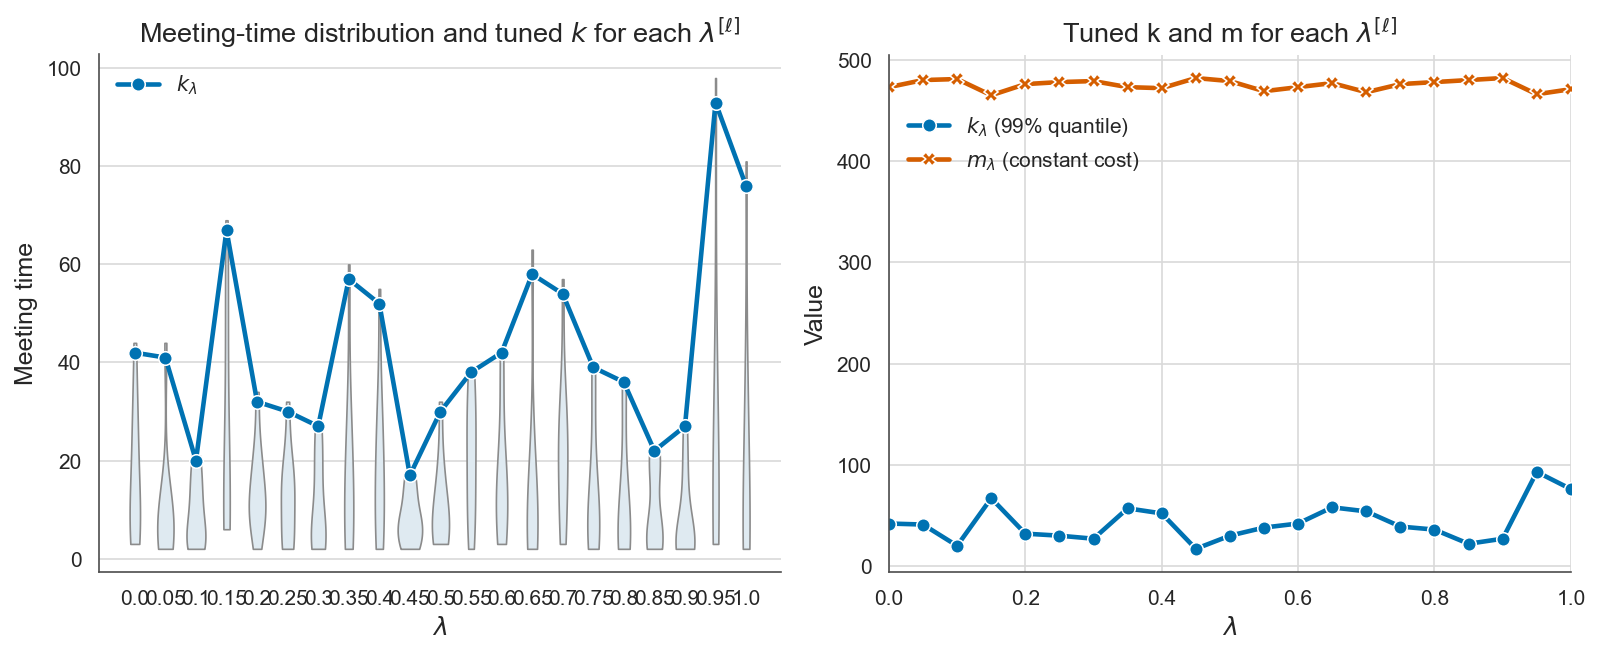

In [7]:
km_grid = tune_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)
plot_km_grid(lambda_grid, lag = lag, sigmaq = sigmaq, log_target_path = log_target_path, nrep = nrep)

Final estimation: 100%|██████████| 21/21 [00:13<00:00,  1.62it/s]


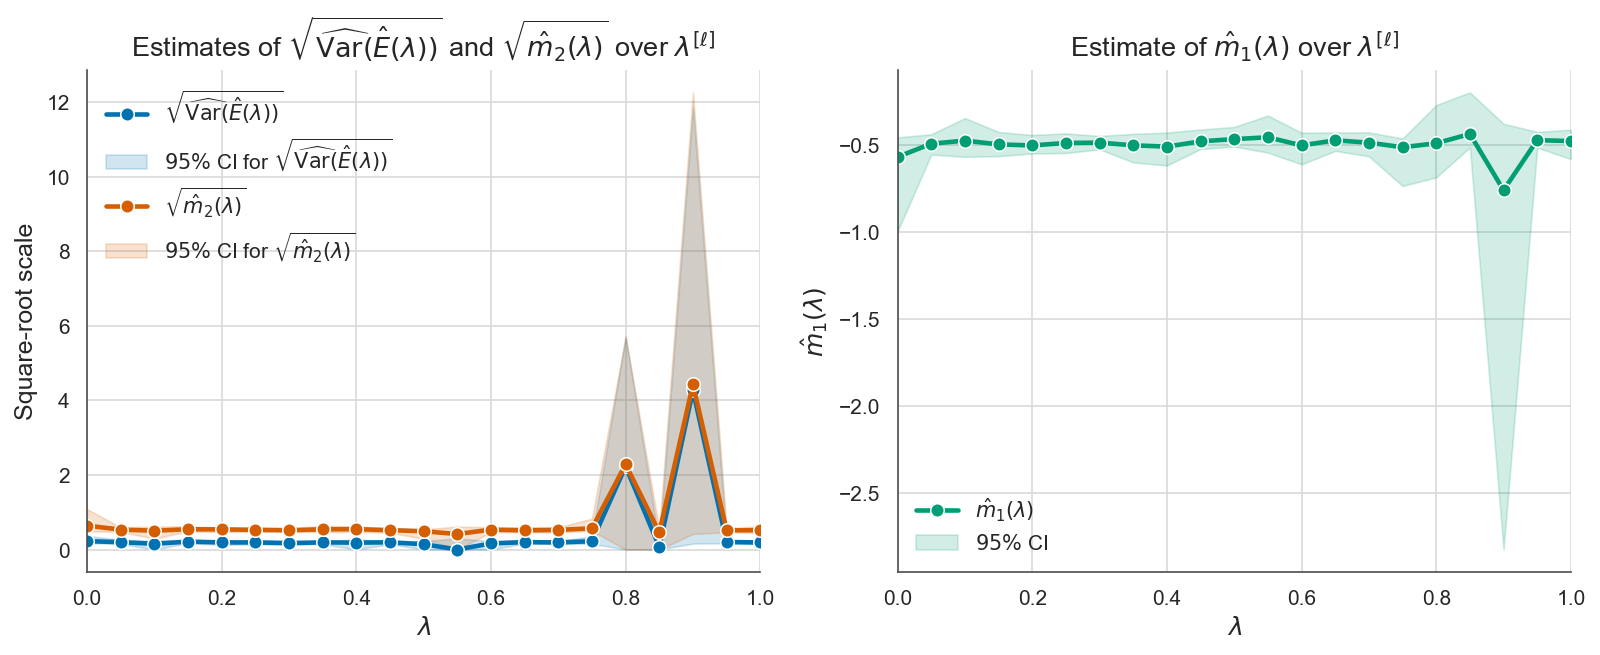

In [8]:
k_grid, m_grid = km_grid["k_grid"], km_grid["m_grid"]
plot_estimate_mom(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

In [9]:
res = estimate_sqrt_m2(lambda_grid, k_grid, m_grid, nrep, sigmaq, lag, log_target_path, grad_log_target_path)

estimation sqrt(m2): 100%|██████████| 21/21 [00:12<00:00,  1.64it/s]


In [13]:
parameter_cache = {}
M_budget = 50
for idx in tqdm(range(n)):
    def log_target_path_i(theta, path):
            return blr_path.log_path(theta, path, idx)
        
    def grad_log_target_path_i(theta):
            return blr_path.log_likelihood_i(theta, idx)
        
    mk_grid_i = tune_km_grid(lambda_grid, lag=lag, sigmaq=sigmaq, log_target_path=log_target_path_i, nrep=nrep)
    # Calcul de sqrt_m2 nécessaire pour la proposal q et stratified
    sqrt_m2_i = estimate_sqrt_m2(lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], nrep, sigmaq, lag, log_target_path_i, grad_log_target_path_i)

    estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

    budget_i = build_budget(L, M_budget, estimator_i, n_samples_per_bin=10)

    # Stockage direct dans le cache
    parameter_cache[idx] = (mk_grid_i, sqrt_m2_i, budget_i)

 51%|█████     | 51/100 [2:13:35<2:08:20, 157.16s/it]


KeyboardInterrupt: 

In [ ]:

# --- Configuration de l'expérience ---
N_grid = [10, 50, 100, 500, 1000, 2000, 5000]  # Différentes valeurs de N_i
num_replicates = 10       # Nombre de répétitions pour chaque N_i

# Calcul de la vraie valeur de référence (somme totale des LOO ELPD exacts)
loo_log_densities_exact, true_total_loo = blr_path.exact_loo_elpd()

# Initialisation du dictionnaire de cache dynamique comme demandé
# Structure : { loo_index: (mk_grid, sqrt_m2, build_budget) }

results_mse = []

print("Début des simulations avec tuning et mise en cache dynamique...")
for N_i in N_grid:
    estimates_is = []
    estimates_strat = []
    
    # Barre de progression pour suivre l'avancée des réplications de chaque N_i
    for rep in tqdm(range(num_replicates), desc=f"Simulation N_i={N_i}"):
        
        # Tirage uniforme de N_i indices parmi les n_total lignes (avec remise)
        sampled_indices = np.random.choice(n, size=N_i, replace=True)
        
        running_sum_is = 0.0
        running_sum_strat = 0.0
        
        for idx in sampled_indices:
            
            # --- RÉCUPÉRATION DU CACHE (Efficience Computationnelle) ---
            # déjà calculé précédemment (ou au-dessus), l'accès prend O(1)
            mk_grid_i, sqrt_m2_i, budget_i = parameter_cache[idx]
            
            # Redéfinition des fonctions pour les passer aux estimateurs
            def log_target_path_i(theta, path):
                return blr_path.log_path(theta, path, idx)
            
            def grad_log_target_path_i(theta):
                return blr_path.log_likelihood_i(theta, idx)
            
            estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

            # --- Estimateur 1 : Stratified Sampling ---
            est_strat_i = optimal_startified_estimator(L, estimator_i, budget_i)
            
            # --- Estimateur 2 : Importance Sampling (q unbiased) ---
            est_is_i = q_unbiased_estimator(L, M_budget, estimator_i, sqrt_m2_i)
            
            running_sum_strat += est_strat_i
            running_sum_is += est_is_i
            
        # Redressement de l'estimateur pour l'ensemble du dataset (n / N_i)
        total_est_strat = (n / N_i) * running_sum_strat
        total_est_is = (n / N_i) * running_sum_is
        
        estimates_strat.append(total_est_strat)
        estimates_is.append(total_est_is)
        
    # Calcul des MSE globaux pour la taille N_i courante
    mse_strat = np.mean((np.array(estimates_strat) - true_value) ** 2)
    mse_is = np.mean((np.array(estimates_is) - true_value) ** 2)
    
    results_mse.append({
        "N_i": N_i,
        "MSE_Stratified": mse_strat,
        "MSE_Importance_Sampling": mse_is
    })

# Affichage des résultats sous forme de tableau de données
df_results = pd.DataFrame(results_mse)
print("\n--- Résultats du MSE pour différents N_i ---")
print(df_results)
print(f"\nNombre total d'indices uniques tunés et mis en cache : {len(parameter_cache)} / {n}")

Début des simulations avec tuning et mise en cache dynamique...


Simulation N_i=50:  60%|██████    | 6/10 [2:26:50<1:37:53, 1468.35s/it]


KeyboardInterrupt: 

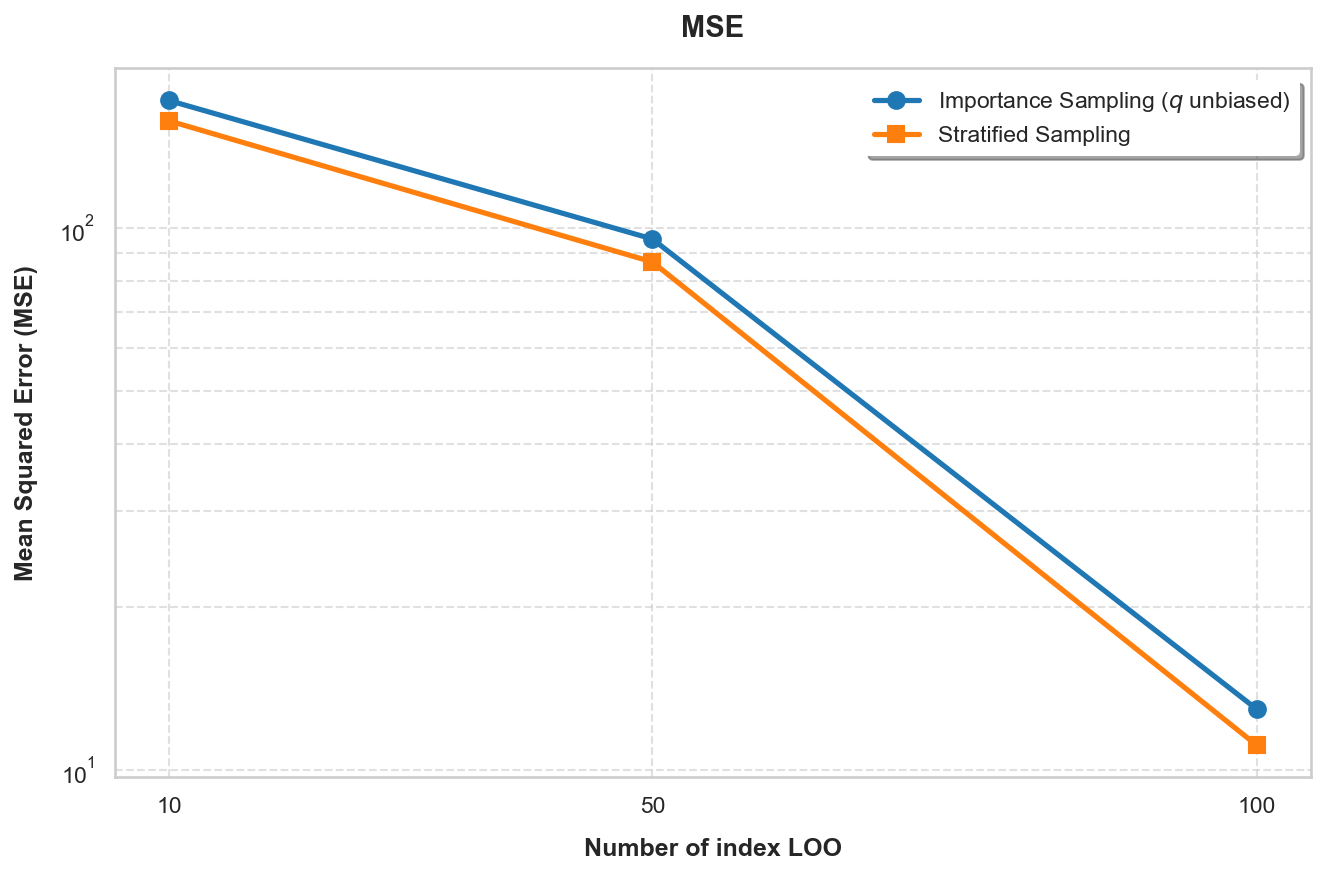

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Application d'un style épuré et professionnel
sns.set_theme(style="whitegrid")

# Création de la figure
plt.figure(figsize=(9, 6), dpi=150)

# Tracé pour Importance Sampling
plt.plot(
    df_results["N_i"], 
    df_results["MSE_Importance_Sampling"], 
    marker="o", 
    markersize=8,
    linewidth=2.5, 
    color="#1f77b4",
    label="Importance Sampling ($q$ unbiased)"
)

# Tracé pour Stratified Sampling
plt.plot(
    df_results["N_i"], 
    df_results["MSE_Stratified"], 
    marker="s", 
    markersize=8,
    linewidth=2.5, 
    color="#ff7f0e",
    label="Stratified Sampling"
)

# Configuration des axes et mise en échelle log pour le MSE
plt.yscale("log")
plt.xlabel("Number of index LOO", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Mean Squared Error (MSE)", fontsize=12, fontweight='bold', labelpad=10)
plt.title("MSE", fontsize=14, fontweight='bold', pad=15)

# Forcer l'affichage de toutes les valeurs de N_i sur l'axe X pour éviter les graduations floues
plt.xticks(df_results["N_i"], labels=[str(n) for n in df_results["N_i"]], fontsize=11)
plt.yticks(fontsize=11)

# Style de la grille d'arrière-plan (grilles principales et secondaires pour le log)
plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Personnalisation de la légende
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=11)

# Ajustement pour éviter que les labels ne débordent
plt.tight_layout()

# Affichage du plot
plt.show()

In [19]:

    # 1) Precompute parameter cache storing a map {budget: budget_i}
parameter_cache = {}
M_budget_list = [50, 100, 200, 500, 1000]
for idx in tqdm(range(n), desc="Tuning / caching indices"):
        def log_target_path_i(theta, path):
                return blr_path.log_path(theta, path, idx)
        def grad_log_target_path_i(theta):
                return blr_path.log_likelihood_i(theta, idx)

        mk_grid_i = tune_km_grid(lambda_grid, lag=lag, sigmaq=sigmaq, log_target_path=log_target_path_i, nrep=nrep)
        sqrt_m2_i = estimate_sqrt_m2(lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], nrep, sigmaq, lag, log_target_path_i, grad_log_target_path_i)

        estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

# build a dict mapping budget value -> budget_i (so we can look up later)
        budget_map = {}
        for budget in M_budget_list:
                budget_i = build_budget(L, budget, estimator_i, n_samples_per_bin=10)
                budget_map[budget] = budget_i

        parameter_cache[idx] = (mk_grid_i, sqrt_m2_i, budget_map)

Tuning / caching indices: 100%|██████████| 40/40 [21:53<00:00, 32.83s/it]


In [36]:
# 2) Run experiments: compute MSE for each (budget, N_i)
N_grid = [10]
num_replicates = 5
loo_log_densities_exact, true_total_loo = blr_path.exact_loo_elpd()

results = []
for M_budget in M_budget_list:

    for N_i in N_grid:
        
        estimates_strat = []
        estimates_is = []
        for rep in tqdm(range(num_replicates), desc=f"Budget={M_budget}, N={N_i}"):
            sampled_indices = np.random.choice(n, size=N_i, replace=True)
            running_sum_strat = 0.0
            running_sum_is = 0.0
            for idx in sampled_indices:
                mk_grid_i, sqrt_m2_i, budget_map = parameter_cache[idx]

                def log_target_path_i(theta, path):
                    return blr_path.log_path(theta, path, idx)
                def grad_log_target_path_i(theta):
                    return blr_path.log_likelihood_i(theta, idx)

                estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

                # lookup stratified budget for this M_budget
                budget_map = parameter_cache[idx][2]
                budget_i = budget_map[M_budget]

                est_strat_i = optimal_startified_estimator(L, estimator_i, budget_i)
                est_is_i = q_unbiased_estimator(L, M_budget, estimator_i, sqrt_m2_i)

                running_sum_strat += est_strat_i
                running_sum_is += est_is_i

            total_est_strat = (n / N_i) * running_sum_strat
            total_est_is = (n / N_i) * running_sum_is

            estimates_strat.append(total_est_strat)
            estimates_is.append(total_est_is)

        mse_strat = np.mean((np.array(estimates_strat) - true_total_loo) ** 2)
        mse_is = np.mean((np.array(estimates_is) - true_total_loo) ** 2)

        results.append({
            "budget": M_budget,
            "N_i": N_i,
            "MSE_Stratified": mse_strat,
            "MSE_Importance_Sampling": mse_is
        })



Budget=1000, N=10: 100%|██████████| 5/5 [44:34<00:00, 534.95s/it]


   budget  N_i  MSE_Stratified  MSE_Importance_Sampling
0      50   10      131.908655               133.938751
1     100   10      224.083478               175.093413
2     200   10      229.591562               228.494216
3     500   10      315.226543               297.548063
4    1000   10       54.406294                44.072183


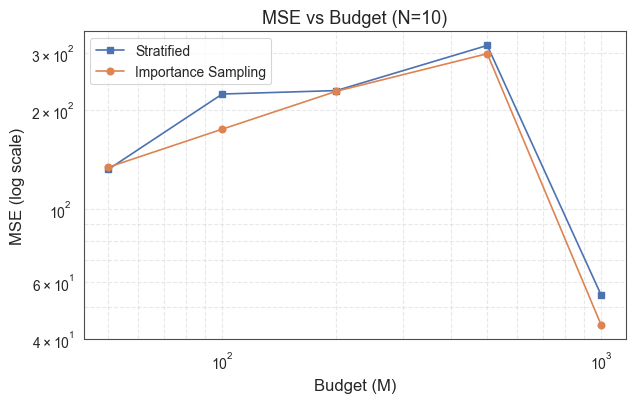

In [38]:

# 3) Aggregate results and (optional) plot MSE vs budget for a chosen N_i (or pivot)
df_results = pd.DataFrame(results)
print(df_results)

# Example pivot: MSE vs budget 
pivot_strat = df_results.pivot(index="budget", columns="N_i", values="MSE_Stratified")
pivot_is = df_results.pivot(index="budget", columns="N_i", values="MSE_Importance_Sampling")

# Quick plot for a chosen N_i (e.g., N_i = 10)
chosen_N = 10
plt.figure(figsize=(7,4))
plt.loglog(pivot_strat.index, pivot_strat[chosen_N], marker='s', label='Stratified')
plt.loglog(pivot_is.index, pivot_is[chosen_N], marker='o', label='Importance Sampling')
plt.xlabel("Budget (M)")
plt.ylabel("MSE (log scale)")
plt.title(f"MSE vs Budget (N={chosen_N})")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.show()

In [8]:
M_budget = 50

idx = np.random.choice(n, size=1, replace=True)
def log_target_path_i(theta, path):
        return blr_path.log_path(theta, path, idx)

def grad_log_target_path_i(theta):
        return blr_path.log_likelihood_i(theta, idx)
        
mk_grid_i = tune_km_grid(lambda_grid, lag=lag, sigmaq=sigmaq, log_target_path=log_target_path_i, nrep=nrep)
    # Calcul de sqrt_m2 nécessaire pour la proposal q et stratified
sqrt_m2_i = estimate_sqrt_m2(lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], nrep, sigmaq, lag, log_target_path_i, grad_log_target_path_i)

estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

budget_i = build_budget(L, M_budget, estimator_i, n_samples_per_bin=10)

    

Computing budget: 100%|██████████| 20/20 [00:03<00:00,  5.15it/s]


In [11]:

# --- Configuration de l'expérience ---
N_grid = [10, 50, 100, 500, 1000]  # Différentes valeurs de N_i
num_replicates = 5       # Nombre de répétitions pour chaque N_i

# Calcul de la vraie valeur de référence (somme totale des LOO ELPD exacts)
loo_log_densities_exact, true_total_loo = blr_path.exact_loo_elpd()

# Initialisation du dictionnaire de cache dynamique comme demandé
# Structure : { loo_index: (mk_grid, sqrt_m2, build_budget) }

results_mse = []

print("Début des simulations avec tuning et mise en cache dynamique...")
for N_i in N_grid:
    estimates_is = []
    estimates_strat = []
    
    # Barre de progression pour suivre l'avancée des réplications de chaque N_i
    for rep in tqdm(range(num_replicates), desc=f"Simulation N_i={N_i}"):
        
        # Tirage uniforme de N_i indices parmi les n_total lignes (avec remise)
        sampled_indices = np.random.choice(n, size=N_i, replace=True)
        
        running_sum_is = 0.0
        running_sum_strat = 0.0
        
        for idx in sampled_indices:
        
            # Redéfinition des fonctions pour les passer aux estimateurs
            def log_target_path_i(theta, path):
                return blr_path.log_path(theta, path, idx)
            
            def grad_log_target_path_i(theta):
                return blr_path.log_likelihood_i(theta, idx)
            
            estimator_i = lambda lam: uestimator_given_lambda(lam, lambda_grid, mk_grid_i["k_grid"], mk_grid_i["m_grid"], sigmaq, lag, log_target_path_i, grad_log_target_path_i)

            # --- Estimateur 1 : Stratified Sampling ---
            est_strat_i = optimal_startified_estimator(L, estimator_i, budget_i)
            
            # --- Estimateur 2 : Importance Sampling (q unbiased) ---
            est_is_i = q_unbiased_estimator(L, M_budget, estimator_i, sqrt_m2_i)
            
            running_sum_strat += est_strat_i
            running_sum_is += est_is_i
            
        # Redressement de l'estimateur pour l'ensemble du dataset (n / N_i)
        total_est_strat = (n / N_i) * running_sum_strat
        total_est_is = (n / N_i) * running_sum_is
        
        estimates_strat.append(total_est_strat)
        estimates_is.append(total_est_is)
        
    # Calcul des MSE globaux pour la taille N_i courante
    mse_strat = np.mean((np.array(estimates_strat) - true_value) ** 2)
    mse_is = np.mean((np.array(estimates_is) - true_value) ** 2)
    
    results_mse.append({
        "N_i": N_i,
        "MSE_Stratified": mse_strat,
        "MSE_Importance_Sampling": mse_is
    })

# Affichage des résultats sous forme de tableau de données
df_results = pd.DataFrame(results_mse)
print("\n--- Résultats du MSE pour différents N_i ---")
print(df_results)
print(f"\nNombre total d'indices uniques tunés et mis en cache : {len(parameter_cache)} / {n}")

Début des simulations avec tuning et mise en cache dynamique...


Simulation N_i=500:  40%|████      | 2/5 [42:08<1:03:12, 1264.19s/it]


KeyboardInterrupt: 

In [ ]:
# Application d'un style épuré et professionnel
sns.set_theme(style="whitegrid")

# Création de la figure
plt.figure(figsize=(9, 6), dpi=150)

# Tracé pour Importance Sampling
plt.plot(
    df_results["N_i"], 
    df_results["MSE_Importance_Sampling"], 
    marker="o", 
    markersize=8,
    linewidth=2.5, 
    color="#1f77b4",
    label="Importance Sampling ($q$ unbiased)"
)

# Tracé pour Stratified Sampling
plt.plot(
    df_results["N_i"], 
    df_results["MSE_Stratified"], 
    marker="s", 
    markersize=8,
    linewidth=2.5, 
    color="#ff7f0e",
    label="Stratified Sampling"
)

# Configuration des axes et mise en échelle log pour le MSE
plt.yscale("log")
plt.xlabel("Number of index LOO", fontsize=20, fontweight='bold', labelpad=10)
plt.ylabel("Mean Squared Error (MSE)", fontsize=20, fontweight='bold', labelpad=10)
plt.title("MSE", fontsize=20, fontweight='bold', pad=15)

# Forcer l'affichage de toutes les valeurs de N_i sur l'axe X pour éviter les graduations floues
plt.xticks(df_results["N_i"], labels=[str(n) for n in df_results["N_i"]], fontsize=11)
plt.yticks(fontsize=11)

# Style de la grille d'arrière-plan (grilles principales et secondaires pour le log)
plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Personnalisation de la légende
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=20)

# Ajustement pour éviter que les labels ne débordent
plt.tight_layout()

# Affichage du plot
plt.show()